Parse JSON IMC Results

In [72]:
import json
import pandas as pd
from io import StringIO

with open('../data/highest_result.json', 'r') as file:
    data = json.load(file)

activities_str = data['activitiesLog']

json_df = pd.read_csv(StringIO(activities_str), sep=';')

Parse Log IMC Results

In [73]:
import json
from io import StringIO
from pathlib import Path
import pandas as pd


def load_highest_result_log(path="../data/highest_result.log"):
    path = Path(path)

    with path.open("r", encoding="utf-8") as f:
        raw = json.load(f)

    print(raw.keys())  # helps confirm field names

    # IMC logs often store the activity table under "activitiesLog"
    # but sometimes the structure can differ, so we check safely.
    activities_text = raw.get("activitiesLog")

    if activities_text is None:
        raise KeyError(f"No 'activitiesLog' key found. Available keys: {list(raw.keys())}")

    activities = pd.read_csv(
        StringIO(activities_text),
        sep=";",
        na_values=["", "null", "None"],
    )

    trades = pd.DataFrame(raw.get("tradeHistory", []))
    sandbox = pd.DataFrame(raw.get("sandboxLogs", []))

    return {
        "submission_id": raw.get("submissionId"),
        "activities": activities,
        "trades": trades,
        "sandbox": sandbox,
        "raw": raw,
    }


parsed = load_highest_result_log()
activities_df = parsed["activities"]
trades_df = parsed["trades"]
sandbox_df = parsed["sandbox"]

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])


IMC CSV Data to DataFrame

In [74]:
day_1_prices = pd.read_csv("../data/prices_round_0_day_-1.csv", sep=";")
day_1_trades = pd.read_csv("../data/trades_round_0_day_-1.csv", sep=";")
day_2_prices = pd.read_csv("../data/prices_round_0_day_-2.csv", sep=";")
day_2_trades = pd.read_csv("../data/trades_round_0_day_-1.csv", sep=";")

Sort Tomatoes Prices

In [75]:
day_1_tom_prices = day_1_prices[day_1_prices["product"] == "TOMATOES"].copy()
day_2_tom_prices = day_2_prices[day_2_prices["product"] == "TOMATOES"].copy()

tom_prices = pd.concat([day_2_tom_prices, day_1_tom_prices])

Sort Tomatoes Trades

In [76]:
day_1_tom_trades = day_1_trades[day_1_trades["symbol"] == "TOMATOES"].copy()
day_2_tom_trades = day_2_trades[day_2_trades["symbol"] == "TOMATOES"].copy()
day_1_tom_trades["day"] = -1
day_2_tom_trades["day"] = -2

tom_trades = pd.concat([day_2_tom_trades, day_1_tom_trades])

Organize Emeralds Prices

In [77]:
day_1_eme_prices = day_1_prices[day_1_prices["product"] == "EMERALDS"].copy()
day_2_eme_prices = day_2_prices[day_2_prices["product"] == "EMERALDS"].copy()

eme_prices = pd.concat([day_2_tom_prices, day_1_eme_prices])

Sort Emeralds Trades

In [78]:
day_1_eme_trades = day_1_trades[day_1_trades["symbol"] == "TOMATOES"].copy()
day_2_eme_trades = day_2_trades[day_2_trades["symbol"] == "TOMATOES"].copy()
day_1_eme_trades["day"] = -1
day_2_eme_trades["day"] = -2

eme_trades = pd.concat([day_2_tom_trades, day_1_tom_trades])

Unique Timestamps

In [79]:
tom_trades["global_time"] = tom_trades["day"] * 1_000_000 + tom_trades["timestamp"]
tom_prices["global_time"] = tom_prices["day"] * 1_000_000 + tom_prices["timestamp"]

eme_trades["global_time"] = eme_trades["day"] * 1_000_000 + eme_trades["timestamp"]
eme_prices["global_time"] = eme_prices["day"] * 1_000_000 + eme_prices["timestamp"]

In [86]:
tom_trades.describe()

,timestamp,buyer,seller,price,quantity,day,global_time
count,846.000000,0.0,0.0,846.000000,846.000000,846.000000,8.460000e+02
mean,488328.841608,NaN,NaN,4977.716312,3.408983,-1.500000,-1.011671e+06
std,277753.137203,NaN,NaN,15.928387,1.103245,0.500296,5.722261e+05
min,3400.000000,NaN,NaN,4943.000000,2.000000,-2.000000,-1.996600e+06
25%,250600.000000,NaN,NaN,4966.000000,2.000000,-2.000000,-1.517075e+06
50%,481500.000000,NaN,NaN,4979.000000,3.000000,-1.500000,-1.000500e+06
75%,733975.000000,NaN,NaN,4990.000000,4.000000,-1.000000,-5.226250e+05
max,995600.000000,NaN,NaN,5010.000000,6.000000,-1.000000,-4.400000e+03


Plotting Price as Line and Trades as Scatter

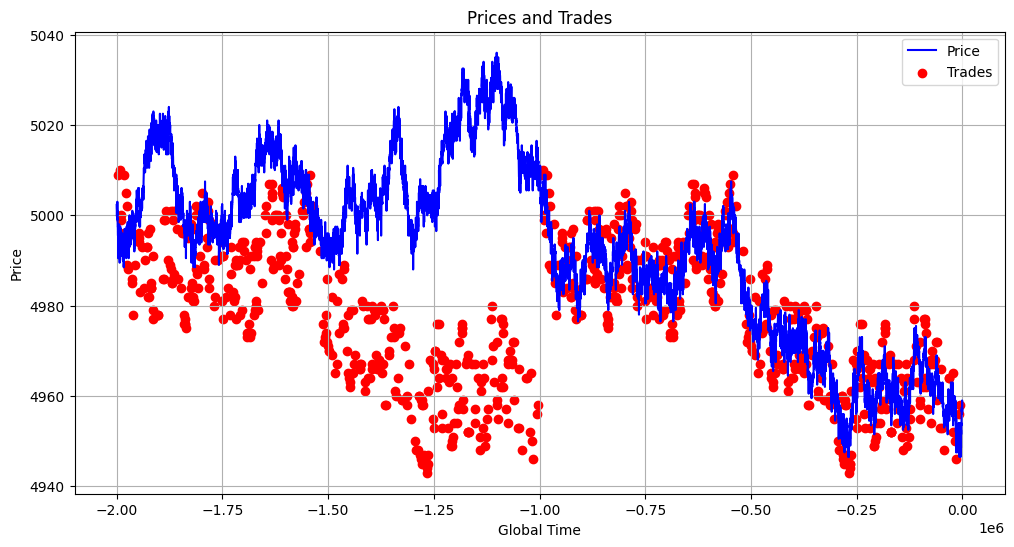

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# line for prices
plt.plot(tom_prices["global_time"], tom_prices["mid_price"], label="Price", color="b")

# scatter for trades
plt.scatter(tom_trades["global_time"], tom_trades["price"], label="Trades", color="red")

plt.xlabel("Global Time")
plt.ylabel("Price")
plt.title("Prices and Trades")
plt.legend()
plt.grid(True)
plt.show()
